# Buổi 5 · Tình huống 09 — Cảnh báo nhập thêm hàng (Adaline)

Notebook này dùng lại bối cảnh trong [`bai-tap/buoi4-tinh-huong/09_canh_bao_nhap_kho.py`](../../bai-tap/buoi4-tinh-huong/09_canh_bao_nhap_kho.py), nhưng thay Perceptron (0/1) bằng **Adaline** học quy tắc Widrow–Hoff (LMS) với **target liên tục**.

Phiên bản này dùng **dữ liệu thực tế**: bộ dữ liệu [*Inventory Demand Forecasting and Stockout Risk*](https://www.kaggle.com/datasets/jayjoshi37/inventory-demand-forecasting-and-stockout-risk/data) trên Kaggle (file `inventory_demand_stockout_risk.csv`, 2800 dòng, mỗi dòng là một sản phẩm quan sát tại một cửa hàng/thời điểm).

## Bối cảnh

Một chuỗi cửa hàng muốn cảnh báo mặt hàng nào cần được nhập thêm trong kỳ kế tiếp, dựa trên dữ liệu tồn kho hiện có.

Các cột có sẵn trong file CSV:

| Cột | Ý nghĩa |
|---|---|
| `product_id`, `date`, `store_id` | định danh sản phẩm / ngày / cửa hàng |
| `current_stock` | tồn kho hiện tại (đơn vị) |
| `daily_demand` | nhu cầu bán trung bình mỗi ngày (đơn vị/ngày) |
| `lead_time_days` | số ngày chờ hàng về sau khi đặt (ngày) |
| `supplier_reliability_score` | điểm tin cậy nhà cung cấp (0–100, càng cao càng đáng tin) |
| `promotion_active` | đang có khuyến mãi hay không (Yes/No) |
| `weather_impact` | mức ảnh hưởng thời tiết đến nhu cầu/vận chuyển (Low/Medium/High) |
| `stockout_risk` | nhãn có sẵn trong bộ dữ liệu gốc: **Yes/No** — có nguy cơ hết hàng hay không |

## Vì sao dùng Adaline thay Perceptron?

Bộ dữ liệu gốc chỉ có nhãn rời rạc `stockout_risk` (Yes/No). Nhưng với việc lập đơn hàng, biết **mức độ khẩn cấp** (một số thực) hữu ích hơn nhiều so với chỉ biết "có/không" — ví dụ để xếp hạng ưu tiên nhập hàng giữa hàng chục sản phẩm cùng lúc.

Vì vậy ở đây ta **tự xây dựng một target liên tục** — gọi là **điểm khẩn cấp** `diem_khan_cap ∈ [0, 1]` — dựa trên một công thức kinh điển trong quản lý tồn kho: **điểm tái đặt hàng (reorder point)**.

$$
\text{reorder\_point} = \text{daily\_demand} \times \text{lead\_time\_days}
$$

Đây là lượng tồn kho tối thiểu cần có để **không bị hết hàng** trong khoảng thời gian chờ lô hàng mới về. Từ đó:

$$
\text{diem\_khan\_cap} = \text{clip}\left(\frac{\text{reorder\_point} - \text{current\_stock}}{\text{reorder\_point}},\ 0,\ 1\right)
$$

- Nếu tồn kho hiện tại **thấp hơn nhiều** so với điểm tái đặt hàng → điểm khẩn cấp gần **1**.
- Nếu tồn kho hiện tại **dư dả** so với điểm tái đặt hàng → điểm khẩn cấp bằng **0**.

Nhắc lại công thức Adaline / Widrow–Hoff mà ta sẽ dùng để *xấp xỉ tuyến tính* điểm khẩn cấp này từ các đặc trưng quan sát được:

$$
\text{net} = \mathbf{w}^\top \mathbf{x} + b, \qquad e = t - \text{net}
$$

$$
\mathbf{w} \leftarrow \mathbf{w} + \eta e \mathbf{x}, \qquad b \leftarrow b + \eta e
$$

**Lưu ý quan trọng:** `current_stock`, `daily_demand`, `lead_time_days` vừa được dùng để **tạo ra target**, vừa được dùng làm **đặc trưng đầu vào**. Điều này không phải data leakage theo nghĩa "dùng thông tin tương lai" (mọi giá trị đều biết tại thời điểm ra quyết định) — nhưng nó có nghĩa là Adaline đang cố học lại (một phần) chính công thức reorder-point, vốn có **phép chia** nên **phi tuyến**. Một mô hình tuyến tính như Adaline sẽ không khớp hoàn hảo được — đây chính là điều ta sẽ quan sát và bàn ở phần Kết luận.

## Nhiệm vụ suy nghĩ

1. Đơn vị quan sát: mỗi dòng trong CSV là **một sản phẩm tại một cửa hàng, một ngày** — đã đúng đơn vị cần cho bài toán.
2. Feature dùng tại thời điểm ra quyết định: `current_stock`, `daily_demand`, `lead_time_days`, `supplier_reliability_score`, `promotion_active`, `weather_impact`. Target `diem_khan_cap` cũng được tính từ các giá trị *hiện tại* này — không dùng thông tin tương lai.
3. Cột `stockout_risk` có sẵn **không** được dùng làm target lúc train — ta để dành nó lại để **đối chiếu, kiểm tra chéo** ở bước đánh giá (rất đáng làm với dữ liệu thật: nhãn có sẵn không phải lúc nào cũng đúng theo logic ta giả định!).
4. Huấn luyện Adaline và giải thích dấu của từng trọng số đã học.
5. Kiểm thử sản phẩm bán chậm, bán nhanh và sản phẩm giả định chưa có trong dữ liệu.

## 1. Thu thập / tạo dữ liệu

Đọc file CSV thật, khám phá nhanh, rồi tạo target liên tục `diem_khan_cap` theo công thức điểm tái đặt hàng ở trên.

In [4]:
import numpy as np
import pandas as pd

# Khai báo đường dẫn file CSV
csv_path = r'C:\Users\Admin\lac-hong-neural-network\data\inventory_demand_stockout_risk.csv'

df = pd.read_csv(csv_path)

print("Kích thước dữ liệu:", df.shape)
df.head()

Kích thước dữ liệu: (2800, 10)


,product_id,date,store_id,current_stock,daily_demand,lead_time_days,supplier_reliability_score,promotion_active,weather_impact,stockout_risk
0,P1000,2024-01-01,S7,213,114,5,72,No,Medium,No
1,P1001,2024-01-02,S20,152,87,7,84,No,High,Yes
2,P1002,2024-01-03,S15,209,62,10,61,No,Low,No
3,P1003,2024-01-04,S11,400,103,10,61,No,Low,No
4,P1004,2024-01-05,S8,60,114,9,75,No,Medium,No


In [5]:
# Kiểm tra nhanh: có giá trị thiếu không, các mức giá trị categorical
print(df.isna().sum())
print()
print("promotion_active:", df["promotion_active"].unique())
print("weather_impact:  ", df["weather_impact"].unique())
print("stockout_risk:   ", df["stockout_risk"].unique(), "- tỉ lệ Yes:",
      (df["stockout_risk"] == "Yes").mean().round(3))

product_id                    0
date                          0
store_id                      0
current_stock                 0
daily_demand                  0
lead_time_days                0
supplier_reliability_score    0
promotion_active              0
weather_impact                0
stockout_risk                 0
dtype: int64

promotion_active: <StringArray>
['No', 'Yes']
Length: 2, dtype: str
weather_impact:   <StringArray>
['Medium', 'High', 'Low']
Length: 3, dtype: str
stockout_risk:    <StringArray>
['No', 'Yes']
Length: 2, dtype: str - tỉ lệ Yes: 0.246


In [6]:
# Tạo target liên tục: điểm khẩn cấp dựa trên "điểm tái đặt hàng" (reorder point)
#   reorder_point = nhu_cầu_mỗi_ngày * số_ngày_chờ_hàng
#   -> lượng tồn tối thiểu cần có để không hết hàng trước khi lô hàng mới về
df["reorder_point"] = df["daily_demand"] * df["lead_time_days"]

df["diem_khan_cap"] = (
    (df["reorder_point"] - df["current_stock"]) / df["reorder_point"]
).clip(0, 1)

df[["current_stock", "daily_demand", "lead_time_days",
    "reorder_point", "diem_khan_cap", "stockout_risk"]].head(10)

,current_stock,daily_demand,lead_time_days,reorder_point,diem_khan_cap,stockout_risk
0,213,114,5,570,0.626316,No
1,152,87,7,609,0.750411,Yes
2,209,62,10,620,0.662903,No
3,400,103,10,1030,0.611650,No
4,60,114,9,1026,0.941520,No
5,267,108,13,1404,0.809829,No
6,261,60,7,420,0.378571,No
7,217,32,5,160,0.000000,Yes
8,282,5,10,50,0.000000,No
9,135,46,10,460,0.706522,No


In [7]:
df["diem_khan_cap"].describe()

count    2800.000000
mean        0.391238
std         0.354825
min         0.000000
25%         0.000000
50%         0.395078
75%         0.728663
max         1.000000
Name: diem_khan_cap, dtype: float64

## 2. Chuẩn hoá feature

Các feature có đơn vị khác nhau (tồn kho có thể lên tới hàng trăm, điểm tin cậy 0–100, ngày chờ chỉ vài ngày...) nên cần đưa về cùng thang đo trước khi huấn luyện Adaline, nếu không feature có giá trị lớn sẽ lấn át các feature khác trong `net`.

Trước tiên ta **mã hoá các cột dạng chữ** thành số (bước này không phụ thuộc thống kê của tập train/test nên làm trước cũng không sao). Việc **tính min–max để co giãn (scale) thì phải đợi tách train/test xong**, và chỉ tính trên tập train — nếu không sẽ bị rò rỉ thông tin (data leakage) từ tập test vào lúc huấn luyện. Vì vậy bước co giãn thực sự sẽ nằm trong cell của mục 3.

In [8]:
# Mã hoá các cột dạng chữ thành số
df["khuyen_mai"] = (df["promotion_active"] == "Yes").astype(float)          # 0/1
weather_map = {"Low": 0.0, "Medium": 0.5, "High": 1.0}                       # thứ tự tăng dần mức ảnh hưởng
df["anh_huong_thoitiet"] = df["weather_impact"].map(weather_map)

feature_cols = [
    "current_stock", "daily_demand", "lead_time_days",
    "supplier_reliability_score", "khuyen_mai", "anh_huong_thoitiet",
]

X_raw = df[feature_cols].to_numpy(dtype=float)
t_all = df["diem_khan_cap"].to_numpy(dtype=float)

print("Số feature:", len(feature_cols), "->", feature_cols)
print("X_raw shape:", X_raw.shape)

Số feature: 6 -> ['current_stock', 'daily_demand', 'lead_time_days', 'supplier_reliability_score', 'khuyen_mai', 'anh_huong_thoitiet']
X_raw shape: (2800, 6)


## 3. Tách train/test

Tách dữ liệu **trước khi chuẩn hoá và huấn luyện** để việc đánh giá sau này khách quan.

In [9]:
from sklearn.model_selection import train_test_split

X_train_raw, X_test_raw, t_train, t_test, df_train, df_test = train_test_split(
    X_raw, t_all, df, test_size=0.2, random_state=42
)

# Chuẩn hoá min-max: fit trên TẬP TRAIN, rồi áp dụng cho cả train và test
x_min = X_train_raw.min(axis=0)
x_max = X_train_raw.max(axis=0)

def chuan_hoa(X):
    return (X - x_min) / (x_max - x_min + 1e-9)

X_train = chuan_hoa(X_train_raw)
X_test = chuan_hoa(X_test_raw)

print("Train:", X_train.shape, " Test:", X_test.shape)

Train: (2240, 6)  Test: (560, 6)


## 4. Cài đặt và huấn luyện Adaline

Cài lại một bước cập nhật Widrow–Hoff (giống `buoi5_adaline_cit.py`), tổng quát hoá cho nhiều feature, rồi huấn luyện qua nhiều epoch trên dữ liệu thật và theo dõi MSE train/test.

Khác với ví dụ 3 mẫu C/I/T (đi đúng thứ tự cố định), với gần 2000 mẫu train ta **xáo trộn thứ tự mỗi epoch** — cách làm chuẩn khi huấn luyện trên dữ liệu thật để tránh mô hình học theo thứ tự mẫu.

In [10]:
def net_output(x, w, b):
    """Adaline: output chính là net = w.x + b (không qua hàm bước)."""
    return np.dot(w, x) + b


def update(x, t, w, b, eta):
    """Một lượt Widrow-Hoff: tính net, sai số liên tục, rồi cập nhật w, b."""
    net = net_output(x, w, b)
    error = t - net
    w_new = w + eta * error * x
    b_new = b + eta * error
    return net, error, w_new, b_new


def mse(X, t, w, b):
    """Sai số bình phương trung bình E = mean(0.5 * e^2)."""
    errors = t - (X @ w + b)
    return np.mean(0.5 * errors ** 2)

In [11]:
ETA = 0.01
N_EPOCHS = 200

n_features = X_train.shape[1]
w = np.zeros(n_features)
b = 0.0

mse_train_hist = []
mse_test_hist = []

rng = np.random.default_rng(42)
idx_all = np.arange(len(X_train))

for epoch in range(N_EPOCHS):
    rng.shuffle(idx_all)
    for i in idx_all:
        _, _, w, b = update(X_train[i], t_train[i], w, b, ETA)
    mse_train_hist.append(mse(X_train, t_train, w, b))
    mse_test_hist.append(mse(X_test, t_test, w, b))

print(f"MSE train: {mse_train_hist[0]:.4f} -> {mse_train_hist[-1]:.4f}")
print(f"MSE test : {mse_test_hist[0]:.4f} -> {mse_test_hist[-1]:.4f}")
print()
print("Trọng số học được:")
for name, wi in zip(feature_cols, w):
    print(f"  {name:28s}: {wi:+.4f}")
print(f"  {'bias (b)':28s}: {b:+.4f}")

MSE train: 0.0152 -> 0.0131
MSE test : 0.0160 -> 0.0138

Trọng số học được:
  current_stock               : -0.7372
  daily_demand                : +0.5914
  lead_time_days              : +0.5770
  supplier_reliability_score  : -0.0132
  khuyen_mai                  : +0.0121
  anh_huong_thoitiet          : +0.0137
  bias (b)                    : +0.1870


## 5. Vẽ đường học (MSE theo epoch)

Quan sát MSE có giảm dần và ổn định hay không.

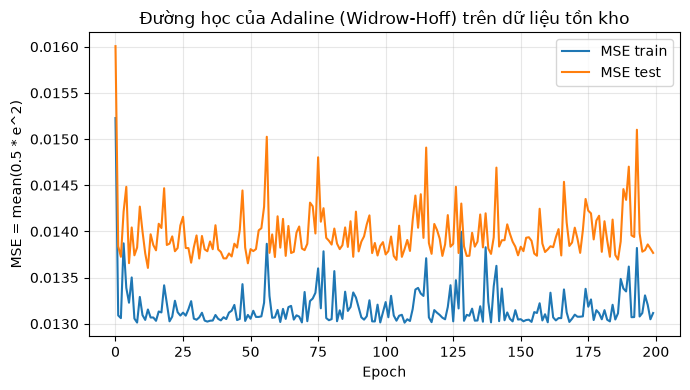

In [12]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 4))
plt.plot(mse_train_hist, label="MSE train")
plt.plot(mse_test_hist, label="MSE test")
plt.xlabel("Epoch")
plt.ylabel("MSE = mean(0.5 * e^2)")
plt.title("Đường học của Adaline (Widrow-Hoff) trên dữ liệu tồn kho")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 6. Đánh giá và phân tích

Xem lại các mẫu có sai số dự đoán lớn nhất, đọc dấu của trọng số và đối chiếu với trực giác nghiệp vụ.

In [13]:
pred_test = X_test @ w + b
errors_test = t_test - pred_test

print("MSE trên tập test:", mse(X_test, t_test, w, b))
print("Sai số tuyệt đối trung bình (MAE):", np.mean(np.abs(errors_test)))

MSE trên tập test: 0.013767358156440713
Sai số tuyệt đối trung bình (MAE): 0.13057695535597652


In [14]:
# 5 mẫu có |sai số| lớn nhất trên tập test
order = np.argsort(-np.abs(errors_test))[:5]

for i in order:
    row = df_test.iloc[i]
    print(
        f"tồn_kho={row['current_stock']:>4}  nhu_cầu={row['daily_demand']:>3}  "
        f"chờ_hàng={row['lead_time_days']:>2} ngày  |  "
        f"target={t_test[i]:.3f}  dự_đoán={pred_test[i]:.3f}  "
        f"sai_số={errors_test[i]:+.3f}  |  nhãn_thật(stockout_risk)={row['stockout_risk']}"
    )

tồn_kho=   4  nhu_cầu=  8  chờ_hàng= 3 ngày  |  target=0.833  dự_đoán=0.292  sai_số=+0.541  |  nhãn_thật(stockout_risk)=No
tồn_kho= 124  nhu_cầu= 88  chờ_hàng= 1 ngày  |  target=0.000  dự_đoán=0.429  sai_số=-0.429  |  nhãn_thật(stockout_risk)=Yes
tồn_kho= 213  nhu_cầu= 16  chờ_hàng=12 ngày  |  target=0.000  dự_đoán=0.428  sai_số=-0.428  |  nhãn_thật(stockout_risk)=No
tồn_kho= 213  nhu_cầu=115  chờ_hàng= 2 ngày  |  target=0.074  dự_đoán=0.498  sai_số=-0.424  |  nhãn_thật(stockout_risk)=Yes
tồn_kho= 149  nhu_cầu= 92  chờ_hàng= 1 ngày  |  target=0.000  dự_đoán=0.416  sai_số=-0.416  |  nhãn_thật(stockout_risk)=Yes


**Đọc dấu trọng số:**

- `current_stock` mang dấu **âm**: tồn kho càng nhiều thì điểm khẩn cấp càng thấp — đúng trực giác.
- `daily_demand` và `lead_time_days` mang dấu **dương**: nhu cầu càng cao và chờ hàng càng lâu thì càng khẩn cấp — đúng trực giác.
- `supplier_reliability_score`, `khuyen_mai`, `anh_huong_thoitiet` có trọng số **nhỏ hơn nhiều** — ba yếu tố này không nằm trong công thức tạo ra target nên đóng góp của chúng chủ yếu đến từ tương quan gián tiếp trong dữ liệu, không mạnh bằng ba đặc trưng cốt lõi ở trên.

### Đối chiếu với nhãn có sẵn `stockout_risk`

Bộ dữ liệu gốc đã có sẵn nhãn Yes/No. Ta chọn một ngưỡng trên `diem_khan_cap` dự đoán để so sánh — xem mô hình có "đồng thuận" với nhãn gốc hay không.

In [15]:
from sklearn.metrics import precision_score, recall_score

actual_binary = (df_test["stockout_risk"].to_numpy() == "Yes")
baseline_acc = max(actual_binary.mean(), 1 - actual_binary.mean())

print(f"Baseline (luôn dự đoán lớp đa số, không cần mô hình): {baseline_acc:.3f}")
print()
for thr in [0.3, 0.4, 0.5, 0.6, 0.7]:
    pred_binary = pred_test >= thr
    acc = (pred_binary == actual_binary).mean()
    prec = precision_score(actual_binary, pred_binary, zero_division=0)
    rec = recall_score(actual_binary, pred_binary, zero_division=0)
    print(f"ngưỡng={thr:.1f}: accuracy={acc:.3f}  precision={prec:.3f}  recall={rec:.3f}")

Baseline (luôn dự đoán lớp đa số, không cần mô hình): 0.764

ngưỡng=0.3: accuracy=0.468  precision=0.250  recall=0.629
ngưỡng=0.4: accuracy=0.530  precision=0.257  recall=0.523
ngưỡng=0.5: accuracy=0.595  precision=0.268  recall=0.417
ngưỡng=0.6: accuracy=0.639  precision=0.273  recall=0.318
ngưỡng=0.7: accuracy=0.689  precision=0.306  recall=0.250


**Nhận xét quan trọng (một bài học thực tế khi làm việc với dữ liệu thật):** accuracy tốt nhất đạt được ở đây **vẫn thấp hơn** baseline "luôn đoán lớp đa số". Điều này cho thấy nhãn `stockout_risk` có sẵn trong file CSV **không tương quan chặt** với quy tắc điểm tái đặt hàng mà ta dùng để tạo `diem_khan_cap` — rất có thể nhãn gốc trong bộ dữ liệu (vốn là dữ liệu tổng hợp/giả lập trên Kaggle) được sinh ra theo một cơ chế khác, hoặc mang nhiễu ngẫu nhiên.

Đây không phải là lỗi của mô hình — mà là lý do vì sao **luôn cần kiểm tra chéo nhãn có sẵn** trước khi tin tưởng tuyệt đối vào nó. Với bài toán thực tế, `diem_khan_cap` (dựa trên logic nghiệp vụ rõ ràng: tồn kho so với điểm tái đặt hàng) vẫn hữu ích để **xếp hạng ưu tiên nhập hàng**, dù nó không trùng khớp hoàn toàn với cột `stockout_risk` có sẵn.

### Kiểm chứng độc lập: có phải do Adaline quá yếu?

Để chắc chắn accuracy thấp là do **đặc điểm của dữ liệu** (nhãn không thể đoán được từ các feature này) chứ không phải do Adaline là mô hình tuyến tính đơn giản, ta thử dùng **Logistic Regression** — một mô hình mạnh hơn, có hàm sigmoid phi tuyến — để dự đoán trực tiếp `stockout_risk` và đo **AUC** (AUC = 0.5 nghĩa là không tốt hơn đoán ngẫu nhiên).

In [16]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score

lr = LogisticRegression(max_iter=1000, class_weight="balanced")
lr.fit(X_train, df_train["stockout_risk"].to_numpy() == "Yes")

auc = roc_auc_score(actual_binary, lr.predict_proba(X_test)[:, 1])
print(f"AUC (Logistic Regression) = {auc:.3f}")
print("(AUC = 0.5 nghĩa là không tốt hơn tung đồng xu; AUC = 1.0 là hoàn hảo)")

AUC (Logistic Regression) = 0.521
(AUC = 0.5 nghĩa là không tốt hơn tung đồng xu; AUC = 1.0 là hoàn hảo)


**AUC ≈ 0.5** — ngay cả một mô hình mạnh hơn Adaline cũng không đoán được nhãn `stockout_risk` tốt hơn ngẫu nhiên. Điều này **xác nhận bằng số liệu** rằng cột nhãn này gần như không có quan hệ thống kê với các feature hiện có trong bộ dữ liệu — đây là một đặc điểm của **dữ liệu** (rất có thể là dữ liệu tổng hợp có nhãn sinh ngẫu nhiên), không phải hạn chế của Adaline hay của cách xây dựng `diem_khan_cap`.

## 7. Chọn ngưỡng và thử nghiệm

Chọn một ngưỡng trên `diem_khan_cap` dự đoán để đưa ra quyết định "cảnh báo nhập hàng" cuối cùng, rồi thử với vài sản phẩm giả định.

In [17]:
NGUONG_CANH_BAO = 0.6  # >= ngưỡng này thì cảnh báo cần nhập thêm hàng

def du_doan_khan_cap(x_tho, w, b, x_min, x_max):
    """Dự đoán điểm khẩn cấp cho MỘT sản phẩm mới từ các giá trị feature THÔ
    (chưa chuẩn hoá), trả về (diem_khan_cap, co_canh_bao).
    """
    x_scaled = (np.asarray(x_tho, dtype=float) - x_min) / (x_max - x_min + 1e-9)
    diem = float(np.dot(w, x_scaled) + b)
    return diem, diem >= NGUONG_CANH_BAO


# 3 sản phẩm giả định: [tồn_kho, nhu_cầu_ngày, ngày_chờ_hàng, điểm_tin_cậy_ncc, khuyến_mãi(0/1), ảnh_hưởng_thời_tiết(0/0.5/1)]
san_pham_gia_dinh = {
    "Bán chậm, tồn nhiều":            [500,  10,  5, 90, 0, 0.0],
    "Bán nhanh, tồn ít, chờ lâu":     [ 50, 120, 10, 60, 1, 1.0],
    "Sản phẩm mới, chưa rõ xu hướng": [150,  50,  7, 75, 0, 0.5],
}

for ten, x_tho in san_pham_gia_dinh.items():
    diem, canh_bao = du_doan_khan_cap(x_tho, w, b, x_min, x_max)
    diem_hien_thi = float(np.clip(diem, 0.0, 1.0))  # giới hạn về [0,1] để báo cáo cho người dùng
    trang_thai = "CẢNH BÁO nhập hàng" if canh_bao else "chưa cần nhập"
    ghi_chu = "  (đã vượt [0,1] do ngoại suy tuyến tính)" if diem != diem_hien_thi else ""
    print(f"{ten:35s} -> diem_khan_cap={diem_hien_thi:.3f}  {trang_thai}  [giá trị thô: {diem:+.3f}]{ghi_chu}")

Bán chậm, tồn nhiều                 -> diem_khan_cap=0.000  chưa cần nhập  [giá trị thô: -0.358]  (đã vượt [0,1] do ngoại suy tuyến tính)
Bán nhanh, tồn ít, chờ lâu          -> diem_khan_cap=1.000  CẢNH BÁO nhập hàng  [giá trị thô: +1.135]  (đã vượt [0,1] do ngoại suy tuyến tính)
Sản phẩm mới, chưa rõ xu hướng      -> diem_khan_cap=0.467  chưa cần nhập  [giá trị thô: +0.467]


**Nhận xét:** với sản phẩm bán nhanh/tồn ít/chờ lâu, điểm dự đoán có thể **vượt quá 1** — vì Adaline là mô hình **tuyến tính không giới hạn miền giá trị**, trong khi target thật đã bị `clip` về [0, 1]. Đây là một giới hạn của Adaline so với các mô hình có hàm kích hoạt bão hoà (như sigmoid trong MLP) — điều này liên hệ trực tiếp tới câu hỏi ở phần Kết luận bên dưới.

## 8. Kết luận

**Adaline với target liên tục có phù hợp hơn Perceptron 0/1 cho tình huống này không?**
Có. Việc dự đoán một điểm số khẩn cấp liên tục cho phép **xếp hạng ưu tiên** nhập hàng giữa nhiều sản phẩm — điều mà nhãn 0/1 của Perceptron không làm được. Nó cũng phản ánh đúng bản chất bài toán: mức độ "cần nhập hàng" vốn là một đại lượng liên tục (ít khẩn cấp → rất khẩn cấp), không phải nhị phân.

**Giới hạn quan sát được:**
1. **Phi tuyến trong chính công thức target:** `diem_khan_cap` được tạo ra từ phép **chia** `(reorder_point - current_stock) / reorder_point` rồi `clip` về [0, 1] — đây là một hàm phi tuyến của `current_stock` và `daily_demand`. Adaline (mô hình tuyến tính) chỉ có thể **xấp xỉ** chứ không khớp hoàn hảo được, thể hiện qua MSE không giảm về gần 0 dù đã huấn luyện nhiều epoch.
2. **Không giới hạn miền giá trị đầu ra:** dự đoán của Adaline có thể vượt ra ngoài [0, 1] khi ngoại suy với sản phẩm có đặc trưng cực đoan (mục 7), trong khi target thực tế luôn nằm trong [0, 1].
3. **Nhãn có sẵn `stockout_risk` không tương quan mạnh** với logic điểm tái đặt hàng mà ta dùng (mục 6), và đã được **kiểm chứng độc lập bằng Logistic Regression (AUC ≈ 0.5)** — chứng minh đây là đặc điểm của dữ liệu chứ không phải hạn chế của Adaline. Một bài học thực tế quan trọng về việc kiểm tra chất lượng/nguồn gốc nhãn trước khi tin dùng.

→ Nếu muốn khớp tốt hơn với các mối quan hệ phi tuyến này (ví dụ tự học đúng dạng phép chia, hoặc tự giới hạn đầu ra trong [0, 1] bằng hàm kích hoạt sigmoid), bước tiếp theo hợp lý là dùng **MLP** (mạng nhiều lớp) — nội dung của buổi học sau.